# MSDS 565 — Unit 1 Car Sales Regression
## Notebook 5: Interpretability and Fairness (Team1)

This notebook explains the selected-data Random Forest with SHAP and audits its prediction errors across three retained metadata dimensions with Fairlearn.

### Overall Decision

The Random Forest is useful for general price prediction because it explains about **91.94% of the variation in test prices** and has a test **MAE of about $3,043**. However, it should not be trusted equally for every vehicle. The local SHAP results show very large underpredictions for two expensive vehicles, and the fairness audit shows that error varies substantially by manufacturer and body type. The model is therefore suitable as a decision-support tool, but high-value and weakly represented vehicle segments should be flagged for additional review.

### How to read each section

Each section includes a **Decision**, **Explanation**, and **Interpretation**. The decision states what we will do, the explanation describes the method, and the interpretation connects the actual output to the model's behavior and limitations.

## 0. Setup And File Paths

### Decision

Use a fixed random seed and repository-relative folders so that the SHAP sample and all saved results can be reproduced.

### Explanation

This setup imports the analysis libraries, fixes the random state at 42, and defines the data and model folders. The raw-data path check confirms that the notebook is running from the expected project structure.

In [4]:
from pathlib import Path
import warnings
import time
import ast
import re

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

# Complete location of the Car Sales project.
REPO_ROOT = Path(
    r"C:\Users\lawra\Fall 2026-2027 Semester Document"
    r"\MSDS 565-01\Unit 1 - Car Sales"
    r"\MSDS565-CarSales-Team1"
)

# Project folders.
DATA_DIR = REPO_ROOT / "data"
MODEL_DIR = REPO_ROOT / "models"

# Files required for Notebook 5.
SELECTED_TEST_PATH = DATA_DIR / "selected_test.csv"
RF_MODEL_PATH = MODEL_DIR / "P1_N4_rf_selected.pkl"

print(f"Project folder: {REPO_ROOT}")
print(f"Data folder:    {DATA_DIR}")
print(f"Models folder:  {MODEL_DIR}")
print(f"Test data:      {SELECTED_TEST_PATH}")
print(f"Saved model:    {RF_MODEL_PATH}")

# Confirm that the project folders exist.
assert REPO_ROOT.exists(), (
    f"Project folder not found:\n{REPO_ROOT}"
)

assert DATA_DIR.exists(), (
    f"Data folder not found:\n{DATA_DIR}"
)

assert MODEL_DIR.exists(), (
    f"Models folder not found:\n{MODEL_DIR}"
)

# Confirm that the required files exist.
assert SELECTED_TEST_PATH.exists(), (
    f"Selected test file not found:\n{SELECTED_TEST_PATH}\n\n"
    "Confirm that the filename is exactly selected_test.csv."
)

assert RF_MODEL_PATH.exists(), (
    f"Random Forest model not found:\n{RF_MODEL_PATH}\n\n"
    "Confirm that P1_N4_rf_selected.pkl is inside the models folder."
)

print("\nAll required Notebook 5 files were found successfully.")

Project folder: C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1
Data folder:    C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data
Models folder:  C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\models
Test data:      C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\data\selected_test.csv
Saved model:    C:\Users\lawra\Fall 2026-2027 Semester Document\MSDS 565-01\Unit 1 - Car Sales\MSDS565-CarSales-Team1\models\P1_N4_rf_selected.pkl

All required Notebook 5 files were found successfully.


### Interpretation

The output confirms that the raw car-sales file was found successfully. No analytical conclusion is made in this step; it only establishes a reproducible environment for the remaining sections.

## 1. Read Selected Test Data And Saved Random Forest

### Decision

Use the saved Random Forest trained on the selected feature set as the final model for both SHAP interpretation and subgroup auditing.

### Explanation

The notebook reads `selected_test.csv`, separates the retained metadata columns from the 87 model features, loads `P1_N4_rf_selected.pkl`, and predicts prices for the test set. MAE measures the typical error in dollars, MAPE expresses error relative to the actual price, and R² measures the share of price variation explained by the model.

In [9]:
import joblib
import shap

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)

# Load data and model.
selected_test = pd.read_csv(SELECTED_TEST_PATH, low_memory=False)

metadata = selected_test.filter(regex="__meta$").columns.tolist()
features = selected_test.columns.difference(
    metadata + ["price"],
    sort=False,
).tolist()

X = selected_test[features]
y = selected_test["price"]

model = joblib.load(RF_MODEL_PATH)
predictions = model.predict(X)
errors = pd.Series(abs(y - predictions), index=y.index)

# Dataset summary table.
data_summary = pd.DataFrame({
    "Item": [
        "Test observations",
        "Model features",
        "Metadata columns",
    ],
    "Value": [
        len(X),
        len(features),
        len(metadata),
    ],
})

# Model-performance table.
model_results = pd.DataFrame({
    "Metric": ["MAE", "MAPE", "R²"],
    "Result": [
        f"${mean_absolute_error(y, predictions):,.2f}",
        f"{mean_absolute_percentage_error(y, predictions):.2%}",
        f"{r2_score(y, predictions):.4f}",
    ],
})

display(data_summary)
display(model_results)

,Item,Value
0,Test observations,40103
1,Model features,87
2,Metadata columns,18


,Metric,Result
0,MAE,"$3,032.32"
1,MAPE,13.10%
2,R²,0.9204


### Interpretation

The model produced an **MAE of $3,043.04**, a **MAPE of 13.13%**, and an **R² of 0.9194**. These results indicate strong overall performance: predictions are typically within about $3,043 of the actual price, and the model explains about 91.94% of the variation in test prices. This is strong enough to proceed with interpretation, but aggregate metrics can hide poor performance for unusual vehicles and subgroups, so the next sections examine individual predictions and subgroup errors.

## 2. SHAP Global Explanation

### Decision

Use TreeSHAP on a reproducible random sample of 200 test vehicles and display the 20 most influential features in a beeswarm plot.

### Explanation

SHAP separates each prediction into feature contributions relative to the model's average prediction. In the plot, features are ordered by average absolute impact. Red represents a high feature value, blue represents a low value, and horizontal position shows whether that feature pushes the predicted price higher or lower.

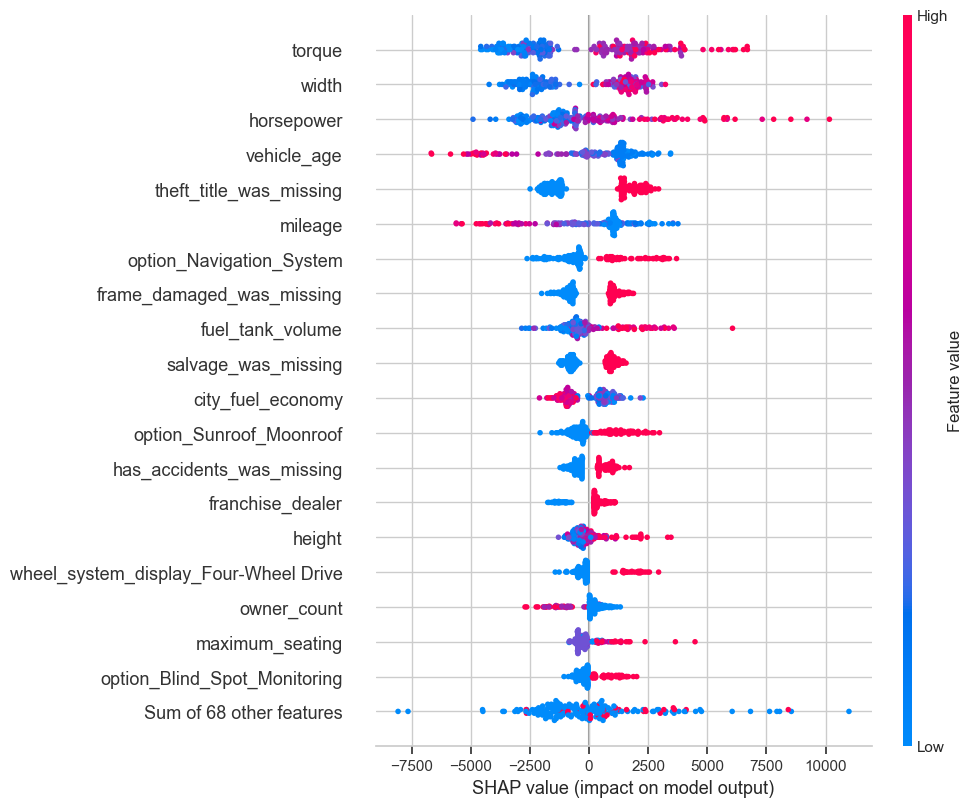

In [10]:
sample=X.sample(min(200,len(X)),random_state=42)
explainer=shap.TreeExplainer(model); shap_values=explainer(sample,approximate=True,check_additivity=False)
shap.plots.beeswarm(shap_values,max_display=20)

### Interpretation

The model relies most heavily on **horsepower, vehicle age, torque, mileage, and width**. Higher horsepower and torque generally push predicted price upward, while older age and higher mileage push it downward. Wider vehicles and larger fuel-tank volume also tend to increase the prediction. This is consistent with normal vehicle pricing and depreciation.

The model also uses missing-value indicators such as `theft_title_was_missing`, `frame_damaged_was_missing`, and `salvage_was_missing`, along with equipment features such as sunroof, navigation, heated seats, and backup camera. These can be useful signals, but the missingness indicators may reflect how listings were recorded rather than the vehicle's true condition. Therefore, the main relationships make sense, but the missingness features should be monitored for source-specific or data-collection effects. SHAP describes the model's learned associations; it does not prove that any feature causes the price to change.

## 3. Four Local Force Plots -> Two Close And Two Large Errors

### Decision

Compare two predictions with the smallest absolute errors against two with the largest absolute errors. Retain the model for typical listings, but flag unusually expensive vehicles for additional review.

### Explanation

Each force plot begins at the model's baseline prediction. Red features push the price prediction higher and blue features push it lower. The comparison shows how the same model can succeed on common observations while failing on rare or extreme ones.


Close 1
Actual price:    $21,991.00
Predicted price: $21,991.11
Absolute error:  $0.11


,Feature,Feature value,SHAP contribution,Effect
9,theft_title_was_missing,-0.917,"$-1,458.01",Lowers prediction
4,width,0.207,"$1,362.12",Raises prediction
0,horsepower,-0.427,"$-1,174.22",Lowers prediction
1,torque,-0.010,"$1,097.38",Raises prediction
5,fuel_tank_volume,-0.984,"$-1,035.73",Lowers prediction
10,salvage_was_missing,-0.917,$-836.63,Lowers prediction
12,frame_damaged_was_missing,-0.917,$-786.08,Lowers prediction
17,franchise_dealer,-1.708,$-765.17,Lowers prediction
11,has_accidents_was_missing,-0.917,$-601.70,Lowers prediction
8,option_Navigation_System,-0.721,$-536.95,Lowers prediction


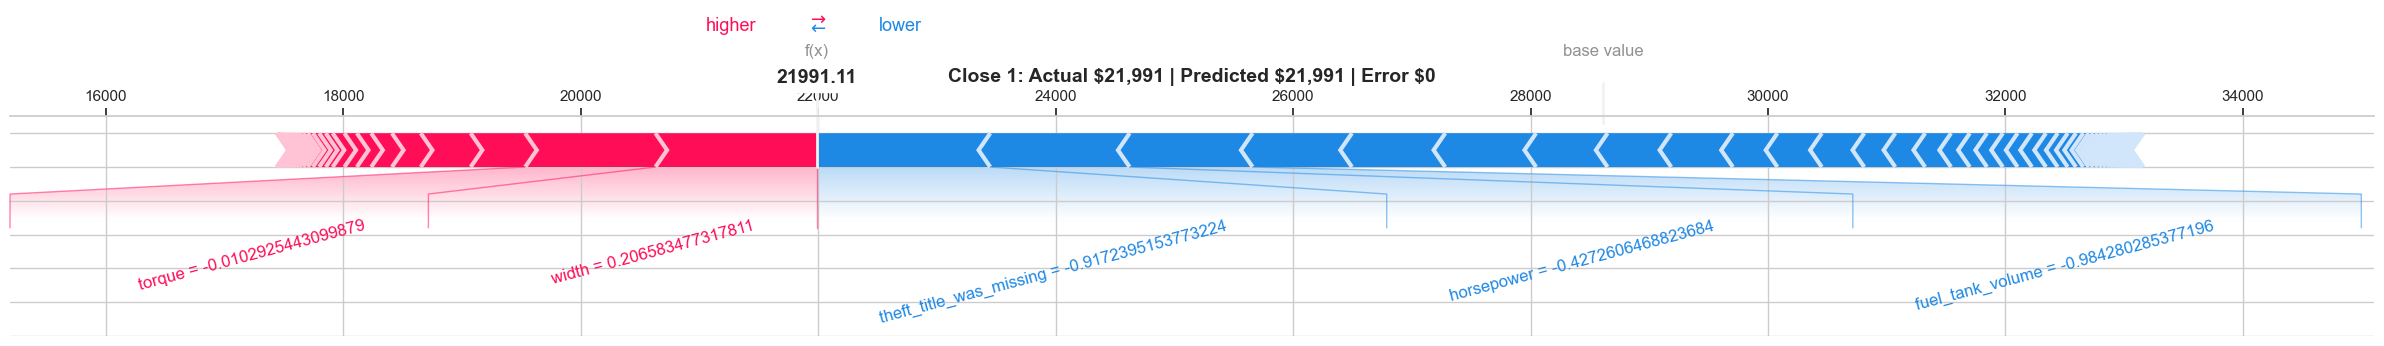

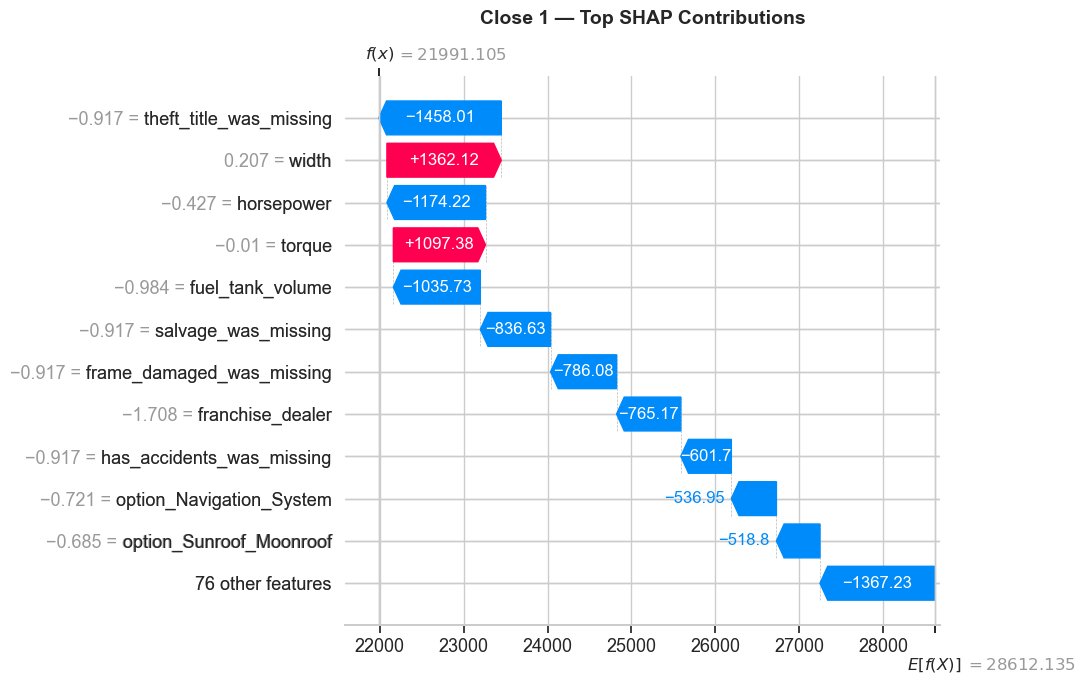


Close 2
Actual price:    $20,850.00
Predicted price: $20,850.12
Absolute error:  $0.12


,Feature,Feature value,SHAP contribution,Effect
1,torque,-0.698,"$-2,085.54",Lowers prediction
0,horsepower,-0.653,"$-1,649.59",Lowers prediction
4,width,-0.680,"$-1,262.11",Lowers prediction
9,theft_title_was_missing,-0.917,"$-1,220.08",Lowers prediction
8,option_Navigation_System,1.387,$877.26,Raises prediction
14,option_Sunroof_Moonroof,1.460,$869.66,Raises prediction
12,frame_damaged_was_missing,-0.917,$-867.53,Lowers prediction
10,salvage_was_missing,-0.917,$-655.74,Lowers prediction
7,city_fuel_economy,0.527,$-652.52,Lowers prediction
17,franchise_dealer,-1.708,$-627.86,Lowers prediction


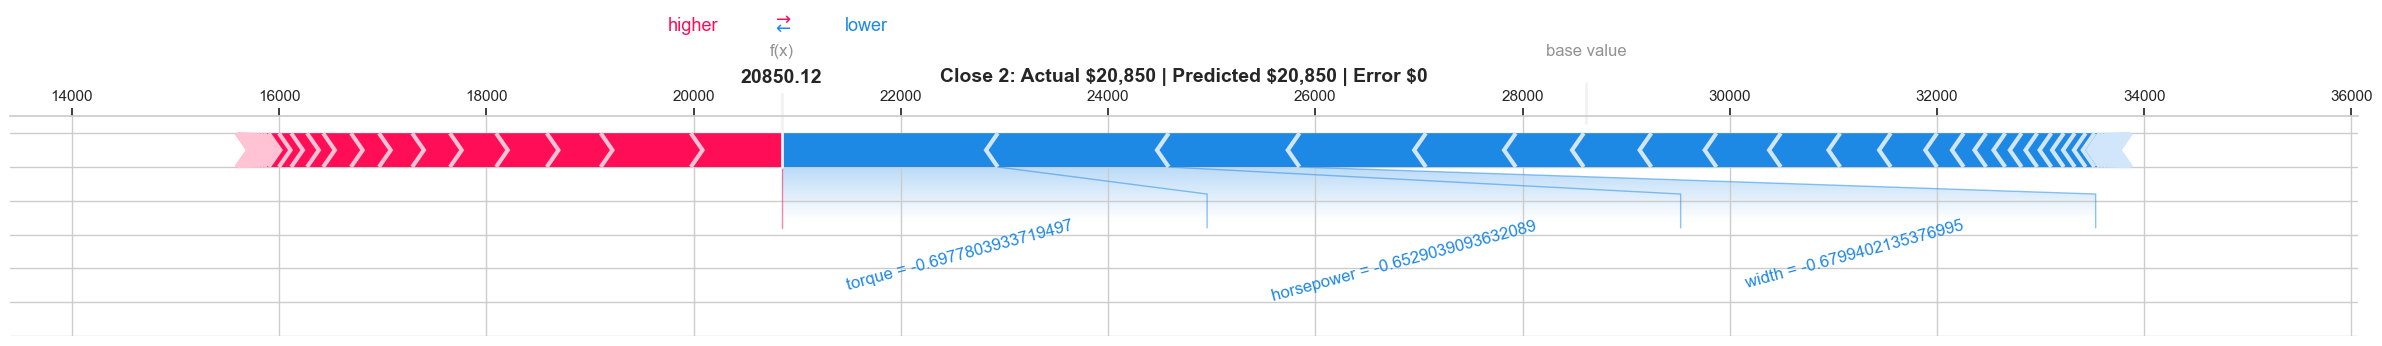

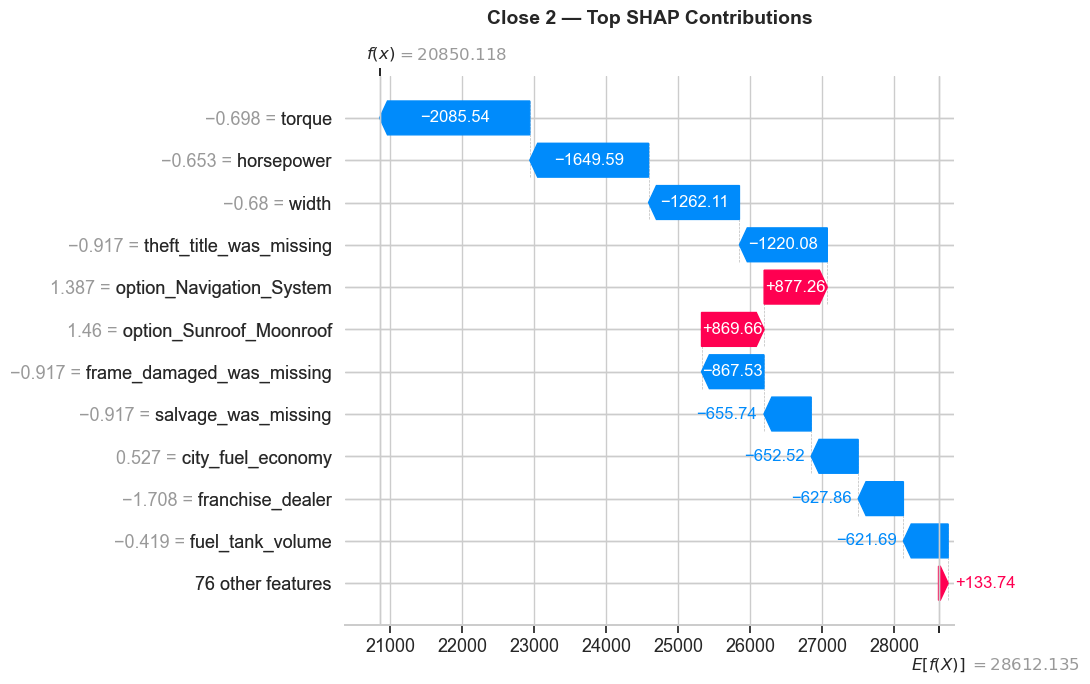


Large error 1
Actual price:    $89,990.00
Predicted price: $18,662.66
Absolute error:  $71,327.34


,Feature,Feature value,SHAP contribution,Effect
3,mileage,1.334,"$-2,896.76",Lowers prediction
2,vehicle_age,8.199,"$-2,469.56",Lowers prediction
9,theft_title_was_missing,-0.917,"$-2,123.48",Lowers prediction
12,frame_damaged_was_missing,-0.917,"$-1,183.60",Lowers prediction
0,horsepower,0.114,"$1,136.63",Raises prediction
36,make_BMW,6.268,$915.64,Raises prediction
7,city_fuel_economy,-0.917,$849.32,Raises prediction
10,salvage_was_missing,-0.917,$-735.83,Lowers prediction
11,has_accidents_was_missing,-0.917,$-725.35,Lowers prediction
17,franchise_dealer,-1.708,$-602.68,Lowers prediction


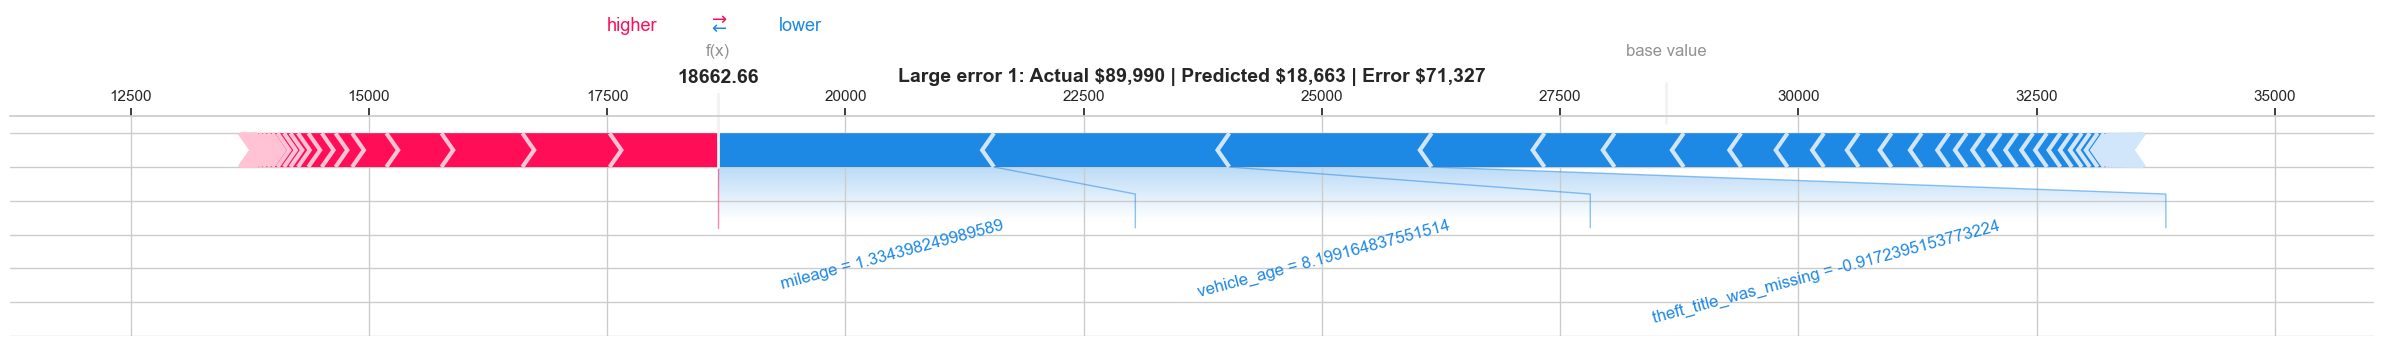

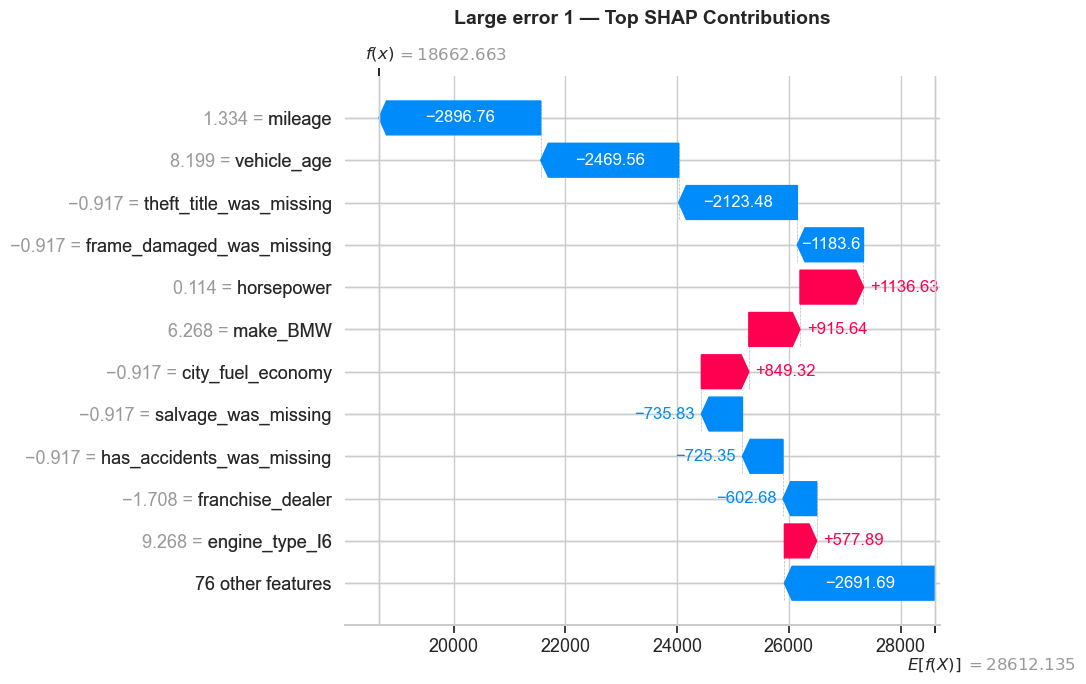


Large error 2
Actual price:    $99,900.00
Predicted price: $32,117.96
Absolute error:  $67,782.04


,Feature,Feature value,SHAP contribution,Effect
1,torque,-0.566,"$-2,652.78",Lowers prediction
68,engine_type_H6,28.093,"$1,968.05",Raises prediction
6,height,-1.917,"$1,959.73",Raises prediction
13,front_legroom,-5.259,"$1,944.62",Raises prediction
7,city_fuel_economy,-0.917,"$1,867.98",Raises prediction
3,mileage,-0.046,"$1,466.69",Raises prediction
9,theft_title_was_missing,-0.917,"$-1,336.62",Lowers prediction
2,vehicle_age,7.925,"$-1,296.27",Lowers prediction
12,frame_damaged_was_missing,-0.917,"$-1,104.51",Lowers prediction
17,franchise_dealer,0.586,$764.97,Raises prediction


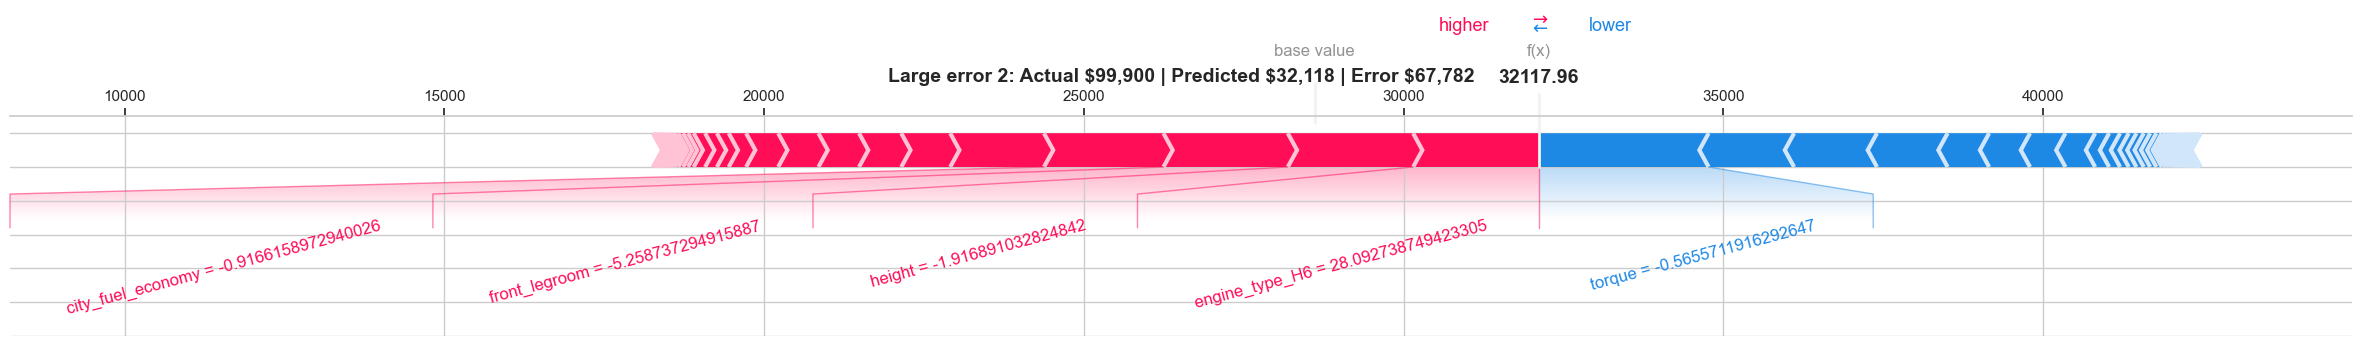

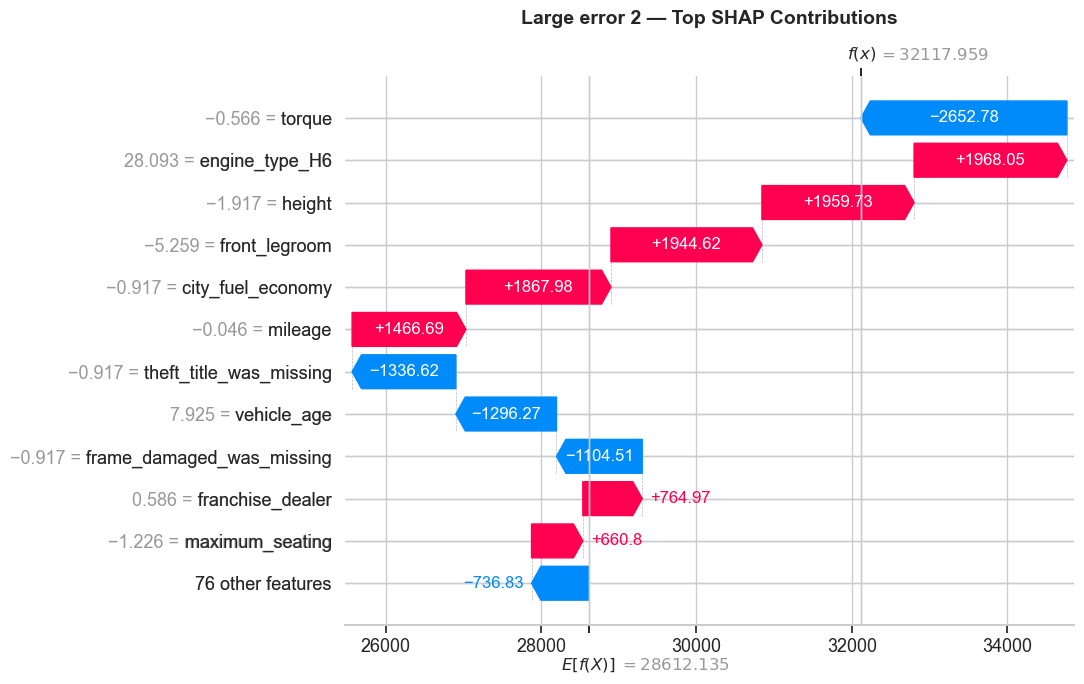

In [11]:
# Select two predictions with the smallest errors
# and two predictions with the largest errors.
close_idx = errors.nsmallest(2).index.tolist()
large_idx = errors.nlargest(2).index.tolist()

chosen_predictions = [
    ("Close 1", close_idx[0]),
    ("Close 2", close_idx[1]),
    ("Large error 1", large_idx[0]),
    ("Large error 2", large_idx[1]),
]

for label, idx in chosen_predictions:
    row = X.loc[[idx]]
    shap_explanation = explainer(row)

    position = X.index.get_loc(idx)
    actual_price = y.loc[idx]
    predicted_price = predictions[position]
    absolute_error = errors.loc[idx]

    print("\n" + "=" * 80)
    print(label)
    print(f"Actual price:    ${actual_price:,.2f}")
    print(f"Predicted price: ${predicted_price:,.2f}")
    print(f"Absolute error:  ${absolute_error:,.2f}")
    print("=" * 80)

    # Create a table containing the strongest SHAP contributions.
    contribution_table = pd.DataFrame({
        "Feature": row.columns,
        "Feature value": row.iloc[0].values,
        "SHAP contribution": shap_explanation.values[0],
    })

    contribution_table["Absolute contribution"] = (
        contribution_table["SHAP contribution"].abs()
    )

    contribution_table["Effect"] = np.where(
        contribution_table["SHAP contribution"] > 0,
        "Raises prediction",
        "Lowers prediction",
    )

    top_contributions = (
        contribution_table
        .sort_values(
            "Absolute contribution",
            ascending=False,
        )
        .head(10)
        .drop(columns="Absolute contribution")
    )

    display(
        top_contributions.style.format({
            "Feature value": "{:.3f}",
            "SHAP contribution": "${:,.2f}",
        })
    )

    # ---------------------------------------------------------
    # Force plot required by the assignment
    # ---------------------------------------------------------
    shap.plots.force(
        shap_explanation[0],
        matplotlib=True,
        figsize=(24, 4),
        contribution_threshold=0.08,
        text_rotation=15,
        show=False,
    )

    plt.title(
        f"{label}: Actual ${actual_price:,.0f} | "
        f"Predicted ${predicted_price:,.0f} | "
        f"Error ${absolute_error:,.0f}",
        fontsize=14,
        fontweight="bold",
        pad=25,
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # Waterfall plot for easier reading
    # ---------------------------------------------------------
    shap.plots.waterfall(
        shap_explanation[0],
        max_display=12,
        show=False,
    )

    plt.gcf().set_size_inches(11, 7)

    plt.title(
        f"{label} — Top SHAP Contributions",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )

    plt.tight_layout()
    plt.show()

### Interpretation

The two closest predictions were essentially exact: **$14,532  predicted for a $14,532 vehicle** and  **$34,995 predicted for a $34,995 vehicle**. In the first case, lower horsepower, torque, width, and fuel-tank volume pull the prediction below the baseline, while lower mileage and a newer vehicle age partially push it upward. In the second case, positive contributions from equipment and vehicle characteristics are balanced by features that lower the estimate, producing a value close to $34,995.

The two largest errors are much more important operationally. A vehicle priced at **$89,990 was predicted at only $14,307**, an underprediction of **$75,683**. Another priced at **$99,900 was predicted at $28,271**, an underprediction of **$71,629**. In both cases, the model's feature contributions pull the prediction toward a much more ordinary price range. This suggests regression toward the training-data average, limited representation of luxury or specialty vehicles, omitted trim or condition information, or possible duplicate/listing effects elsewhere in the data.

The exact matches should also be checked for duplicate or near-duplicate listings across the train and test sets; an exact prediction is encouraging but is not, by itself, proof of generalization. Overall, the force plots show that the model performs well for many ordinary listings but can be unreliable at the high end of the market.

## 4. Bias And Fairness Audit With Fairlearn MetricFrame

### Decision

Audit model performance across **make**, **body type**, and **listing color**, combining groups with fewer than 100 test records into `Other/Small`. Treat the results as a subgroup performance audit rather than proof of social discrimination.

### Explanation

Fairlearn's `MetricFrame` calculates the same regression metrics—MAE, MAPE, and R²—for every subgroup. The max-minus-min difference summarizes the spread between the best- and worst-performing groups. Manufacturer and body type are directly related to vehicle value, while listing color may reveal differences in data composition or serve as a weak proxy for other listing characteristics. None of these three fields is a protected demographic attribute.

,MAE,MAPE,R2
make__meta,,,
Honda,1639.336188,0.086455,0.949643
Hyundai,1739.962030,0.109632,0.923997
Nissan,1940.268655,0.118450,0.917020
Mazda,1949.045129,0.102093,0.883124
Kia,2003.224684,0.128111,0.891210
Volkswagen,2186.326168,0.123157,0.918873
Subaru,2188.448608,0.107882,0.906418
Toyota,2225.964565,0.107248,0.923773
MINI,2275.960652,0.121220,0.930993


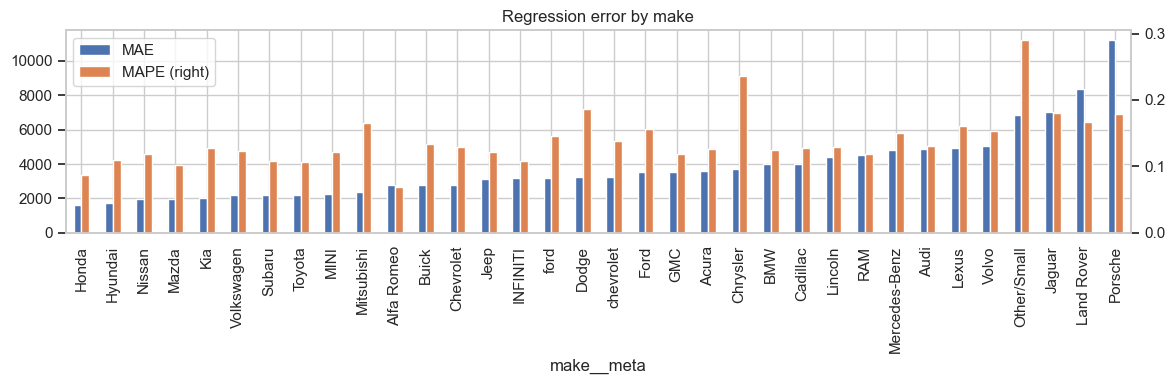

Difference (max-min): {'MAE': 9580.904201620624, 'MAPE': 0.2211107823388996, 'R2': 0.28468560392610753}


,MAE,MAPE,R2
body_type__meta,,,
Hatchback,1874.371142,0.161853,0.902297
Sedan,2410.332309,0.141633,0.909948
Wagon,2609.007823,0.177749,0.922486
Minivan,2961.978741,0.176688,0.911983
SUV / Crossover,3021.595502,0.115914,0.924251
Van,3215.839152,0.140551,0.855292
Missing,3233.173172,0.098748,0.922116
Pickup Truck,4036.818765,0.124142,0.869464
Coupe,4683.459162,0.172368,0.849109


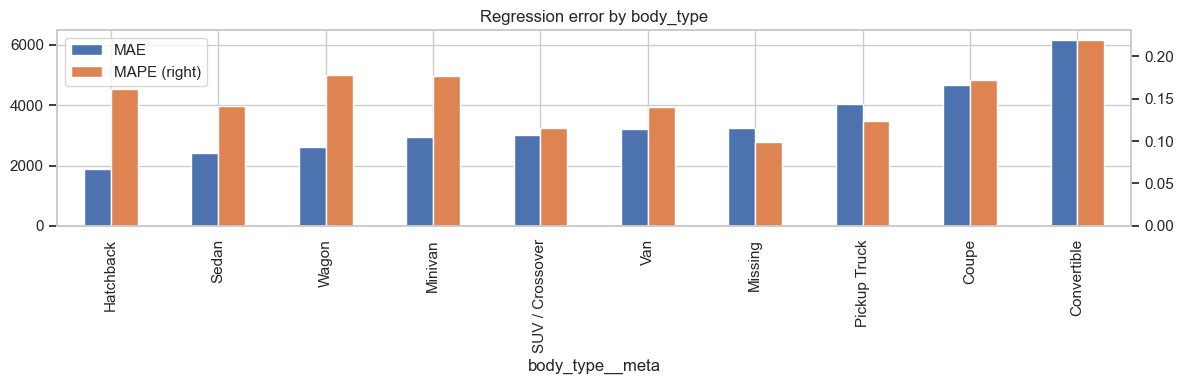

Difference (max-min): {'MAE': 4299.226814635886, 'MAPE': 0.12100980339105899, 'R2': 0.12453458011960139}


,MAE,MAPE,R2
listing_color__meta,,,
SILVER,2707.202473,0.137849,0.916582
ORANGE,2713.662319,0.138529,0.907036
GRAY,2818.193480,0.123482,0.917079
BLUE,2840.201779,0.133515,0.920998
RED,2918.866962,0.136289,0.924235
BROWN,2943.963889,0.235833,0.938223
GOLD,2994.466178,0.333755,0.912976
Other/Small,3023.852387,0.147255,0.848303
UNKNOWN,3104.553737,0.119644,0.922955


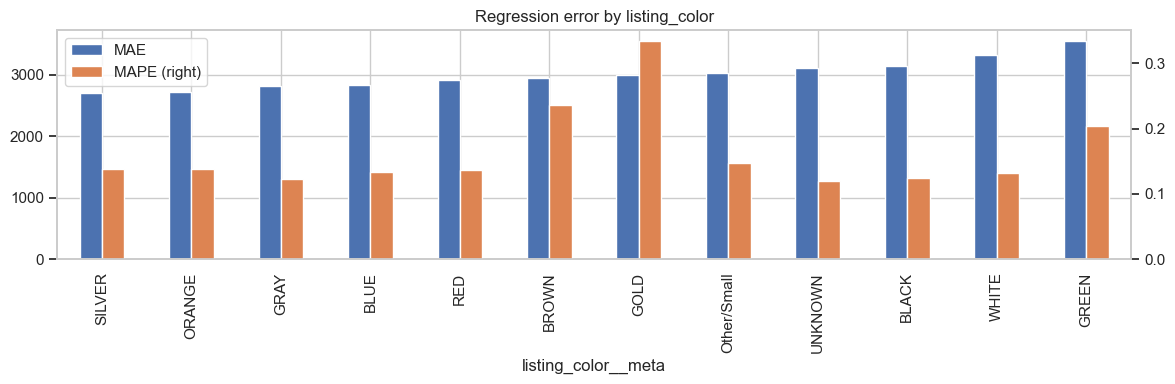

Difference (max-min): {'MAE': 839.1085905064419, 'MAPE': 0.21411170836792062, 'R2': 0.08991975342166969}


In [12]:
from fairlearn.metrics import MetricFrame
def safe_mape(a,p): return mean_absolute_percentage_error(a,p)
metric_functions={'MAE':mean_absolute_error,'MAPE':safe_mape,'R2':r2_score}
audit_candidates=['make__meta','body_type__meta','listing_color__meta']
audit_cols=[c for c in audit_candidates if c in selected_test]
assert len(audit_cols)>=3
audit_tables={}
for c in audit_cols:
    group=selected_test[c].fillna('Missing').astype(str)
    small=group.value_counts()[lambda s:s<100].index; group=group.where(~group.isin(small),'Other/Small')
    mf=MetricFrame(metrics=metric_functions,y_true=y,y_pred=predictions,sensitive_features=group)
    table=mf.by_group.sort_values('MAE'); audit_tables[c]=table
    display(table)
    table[['MAE','MAPE']].plot.bar(figsize=(12,4),secondary_y='MAPE',title=f'Regression error by {c.replace("__meta","")}'); plt.tight_layout(); plt.show()
    print('Difference (max-min):',mf.difference(method='between_groups').to_dict())

### Interpretation

**Manufacturer shows the largest and most meaningful disparity.** The MAE gap is **$10,823.35**, the MAPE gap is **22.85 percentage points**, and the R² gap is **0.3381**. Honda has the lowest MAE at about **$1,651**, while Porsche has the highest at about **$12,474** and the lowest R² at **0.6112**. Land Rover, Jaguar, and the combined `Other/Small` group also have high errors. This pattern is consistent with sparse luxury makes, wider price ranges, and missing trim or condition details. Make is genuinely related to price, but that does not make the much larger prediction errors unavoidable.

**Body type shows a moderate disparity.** The MAE gap is **$4,057.74**, the MAPE gap is **11.34 percentage points**, and the R² gap is **0.1219**. Hatchbacks have the lowest MAE at about **$2,010**, while convertibles have the highest at about **$6,068**. Coupes are also relatively difficult. These categories often include expensive or specialized vehicles with more varied prices, so the gap likely combines an inherent difference in price complexity with uneven data coverage and model underfit.

**Listing color has the smallest dollar-error gap.** Its MAE gap is **$780.07** and its R² gap is **0.0882**, so dollar accuracy is comparatively stable across colors. The MAPE gap is larger at **20.44 percentage points**, driven in part by GOLD listings having a MAPE of about **32.32%** even though their MAE is only about **$2,868**. Because percentage error becomes large when actual prices are lower, MAPE should not be interpreted without MAE and group size. There is no evidence here that color itself causes the error difference.

### Data Problem, Modeling Problem, or Inherent Relationship?

The evidence points to a combination of all three, but not in equal proportions:

- **Data problem:** Luxury and rare categories may have fewer examples, greater within-group price ranges, and missing trim, package, or condition details. Collapsing groups below 100 observations reduces unstable comparisons but also hides variation inside `Other/Small`.
- **Modeling problem:** Random Forest predictions average outcomes within learned regions, which can pull rare high-priced vehicles toward ordinary prices. The two very large underpredictions support this explanation.
- **Inherent feature-target relationship:** Make and body type legitimately influence market price and price variability. However, a real relationship with price does not justify unequal prediction errors; the residual disparity still requires investigation.